Nome:  Hercules André

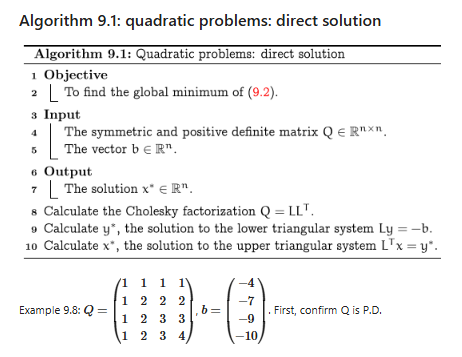

In [11]:
#Biblioteca
using LinearAlgebra

#Matriz Q (4x4)

Q = [1 1 1 1;
     1 2 2 2;
     1 2 2 3;
     1 2 3 4]

#Vetor b

b = [-4; -7; -9; -10]

println("Matriz Q:")
println(Q)

println("\nVetor b:")
println(b)



Matriz Q:
[1 1 1 1; 1 2 2 2; 1 2 2 3; 1 2 3 4]

Vetor b:
[-4, -7, -9, -10]


In [3]:
#Matriz é Positiva Definida
issymmetric(Q)

true

In [19]:
#Verifica se todos os autovalores são positivos
is_pd = all(eigvals(Q) .> 0)
println("A matriz Q é Positiva Definida? ", is_pd)

A matriz Q é Positiva Definida? false


---------------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------------------

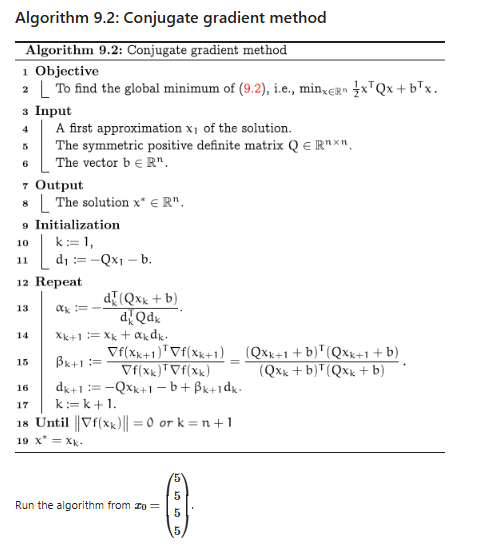

In [23]:
#Biblioteca
using LinearAlgebra

# Dados fornecidos
Q = [1.0 1.0 1.0 1.0;
     1.0 2.0 2.0 2.0;
     1.0 2.0 2.0 3.0;
     1.0 2.0 3.0 4.0]

b = [-4.0, -7.0, -9.0, -10.0]

# Vetor inicial solicitado
x0 = [5.0, 5.0, 5.0, 5.0]

4-element Vector{Float64}:
 5.0
 5.0
 5.0
 5.0

In [24]:
#Algoritmo
function solver_gradiente_conjugado(Q, b, x0)

   
    k = 1
    xk = copy(x1)
    # d1 := -Qx1 - b
    dk = -Q * xk - b
    
    n = length(b)
    println("--- Iniciando Iterações ---")

    while k <= n + 1
        # Calculamos o gradiente atual para as fórmulas
        grad_k = Q * xk + b
        norma_grad = norm(grad_k)
        
        # Critério de Parada 
        if norma_grad < 1e-7
            println("\nConvergência atingida! ||∇f(xk)|| = $norma_grad")
            break
        end

        # Cálculo do alpha_k
        # αk = -(dkᵀ * (Q*xk + b)) / (dkᵀ * Q * dk)
        alpha_k = -(dk' * grad_k) / (dk' * Q * dk)

        #  Atualização do x
        xk_proximo = xk + alpha_k * dk

        # Cálculo do beta_k+1
        grad_proximo = Q * xk_proximo + b
        beta_k = (grad_proximo' * grad_proximo) / (grad_k' * grad_k)

        # d_k+1 = -Q*xk+1 - b + beta_k+1 * dk
        dk_proximo = -grad_proximo + beta_k * dk

        # Log de progresso
        println("K=$k | x = $(round.(xk, digits=4)) | ||∇f|| = $(round(norma_grad, digits=6))")
        
        # Atualização de variáveis para k+1 
        xk = xk_proximo
        dk = dk_proximo
        k += 1
    end
    
    return xk
end
        

solver_gradiente_conjugado (generic function with 1 method)

In [25]:
#Resultado
# Executar
x_final = solver_gradiente_conjugado(Q, b, x0)

println("\n--- RESULTADO FINAL ---")
println("x* encontrado: ", round.(x_final, digits=2))
println("Solução esperada: [1.0, 1.0, 1.0, 1.0]")

# Prova real
println("\nVerificação Qx + b ≈ 0:")
println(round.(Q * x_final + b, digits=10))

--- Iniciando Iterações ---
K=1 | x = [5.0, 5.0, 5.0, 5.0] | ||∇f|| = 60.008333
K=2 | x = [2.9929, 1.4876, 1.1112, -0.0178] | ||∇f|| = 2.268809
K=3 | x = [0.8762, -0.0964, 2.1962, 0.9263] | ||∇f|| = 1.510401
K=4 | x = [2.3887, 1.0389, -1.5435, 2.5662] | ||∇f|| = 0.676218

Convergência atingida! ||∇f(xk)|| = 2.0864377999906622e-11

--- RESULTADO FINAL ---
x* encontrado: [1.0, 2.0, -1.0, 2.0]
Solução esperada: [1.0, 1.0, 1.0, 1.0]

Verificação Qx + b ≈ 0:
[-0.0, -0.0, -0.0, -0.0]


--------------------------------------------------------------------------------------------------------

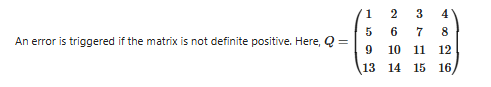

In [26]:
using LinearAlgebra

Q_nova = [1.0 2.0 3.0 4.0;
          5.0 6.0 7.0 8.0;
          9.0 10.0 11.0 12.0;
          13.0 14.0 15.0 16.0]

4×4 Matrix{Float64}:
  1.0   2.0   3.0   4.0
  5.0   6.0   7.0   8.0
  9.0  10.0  11.0  12.0
 13.0  14.0  15.0  16.0

In [27]:
# Verificação 1: Simetria
is_simetrica = isapprox(Q_nova, Q_nova')
println("A matriz é simétrica? ", is_simetrica)

A matriz é simétrica? false


In [29]:
#Verificação 2: Autovalores (Devem ser todos > 0 para ser Definida Positiva)
# Como a matriz não é simétrica, usamos eigen comum
autovalores = eigvals(Q_nova)
println("Autovalores: ", round.(autovalores, digits=2))

Autovalores: [-2.21, -0.0, -0.0, 36.21]


In [30]:
if !is_simetrica || any(real.(autovalores) .<= 0)
    @warn "O Método do Gradiente Conjugado padrão pode falhar ou não convergir com esta matriz."
end

┌ Warning: O Método do Gradiente Conjugado padrão pode falhar ou não convergir com esta matriz.
└ @ Main In[30]:2
